#  Distributed Machine Learning using Ray
### Parallel and Distributed Computing Project

Group Members:
- Aqsa Fida (014)
- Mishal Raziq (064)
- Rabbia Noor (070)
- Eman Khalid (026)


 Objective:

***To implement distributed machine learning using Ray and compare performance with traditional (non-distributed) approaches.***


This notebook demonstrates:
- Part 1: Ray Installation & Basic Parallel Tasks
- Part 2: Distributed Hyperparameter Tuning
- Part 3: Distributed Model Training
- Part 4: Performance Comparison & Visualization


"""
Distributed Computing vs Parallel Computing

Parallel Computing:
- Execution of multiple tasks simultaneously using multiple CPU cores on a single machine.

Distributed Computing:
- Distributed computing refers to executing tasks across multiple workers.

Why is it important in Machine Learning?

- Machine Learning models require processing large datasets.
- Sequential execution is slow and inefficient.
- Distributed computing reduces execution time and improves scalability.
- Enables real-world applications such as:
    - Predictive maintenance
    - Cloud infrastructure monitoring
    - Failure detection systems
"""

"""
What is Ray?

Ray is a distributed computing framework in Python that enables parallel
and distributed execution of tasks efficiently.

Why use Ray?

- Python executes code sequentially by default.
- Traditional multiprocessing is complex and harder to scale.
- Ray provides:
    ✔ Simple parallelization using @ray.remote
    ✔ Efficient CPU utilization
    ✔ Scalable architecture for large workloads

Key Features:

1. Tasks → Stateless parallel functions
2. Actors → Stateful workers
3. Distributed execution across CPU cores
4. Scalable from single machine to clusters
"""

# Install Dependencies

In [2]:
!pip install ray scikit-learn pandas matplotlib

import ray
import multiprocessing
import pandas as pd
import time
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


# Initialize Ray

"""
Ray is initialized using all available CPU cores to maximize parallel execution.
This ensures efficient utilization of system resources.
"""

In [3]:
ray.init(num_cpus=multiprocessing.cpu_count(), ignore_reinit_error=True)

print("CPU Cores:", multiprocessing.cpu_count())

2026-04-26 21:25:10,625	INFO worker.py:2013 -- Started a local Ray instance.


CPU Cores: 4


/usr/local/lib/python3.12/dist-packages/ray/_private/worker.py:2052: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


##  Part 1: Convert Code to Ray Tasks

###  1.1 DATASET LOADING AND PREPROCESSING

Key operations performed:
- Converted datetime column into useful numerical features (year, month, day, hour)
- Removed the original datetime column
- Converted categorical variables into numeric format using one-hot encoding
- Handled missing values using mean imputation
- Increased dataset size to simulate a heavier workload for better parallel performance.

In [4]:
df = pd.read_csv("/kaggle/input/datasets/rabbianoor07/azure-vm-data/azure_vm_predictive_data.csv")

# Handle datetime
if "datetime" in df.columns:
    df["datetime"] = pd.to_datetime(df["datetime"])
    df["year"] = df["datetime"].dt.year
    df["month"] = df["datetime"].dt.month
    df["day"] = df["datetime"].dt.day
    df["hour"] = df["datetime"].dt.hour
    df.drop("datetime", axis=1, inplace=True)

# Convert categorical → numeric
df = pd.get_dummies(df, drop_first=True)

#  Handle NaN
df = df.fillna(df.mean(numeric_only=True))

# Split
X = df.drop("failure_flag", axis=1)
y = df["failure_flag"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

###  1.2 NON-DISTRIBUTED MODEL (SEQUENTIAL EXECUTION)

In this step, we train multiple Random Forest models sequentially.

Key characteristics:
- No parallelism is used
- Execution is performed on a single processing flow

This serves as a baseline to compare performance with the distributed (Ray-based) implementation.

In [5]:
params = [1, 10, 50, 100]

start = time.time()

non_ray_results = []

for n in params:
    model = RandomForestClassifier(
        n_estimators=n,
        n_jobs=1,        # ensures no internal parallelism
        random_state=42
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    non_ray_results.append((n, acc))

end = time.time()

non_ray_time = end - start

print("Sequential Results:", non_ray_results)
print("Sequential Time:", non_ray_time)

Sequential Results: [(1, 0.9992500803485341), (10, 0.999625040174267), (50, 0.9997500267828447), (100, 0.9997857372424384)]
Sequential Time: 150.51905846595764


### 1.5 DATA SHARING USING RAY OBJECT STORE

To improve efficiency, we store training and testing data in Ray’s distributed object store.This avoids repeatedly copying large datasets to each worker.

In [6]:
X_train_ref = ray.put(X_train)
y_train_ref = ray.put(y_train)
X_test_ref = ray.put(X_test)
y_test_ref = ray.put(y_test)

###  1.6 CONVERTING FUNCTION INTO RAY REMOTE TASK

In this step, we convert a normal training function into a Ray remote function using @ray.remote.

Key idea:
- Each function call becomes an independent task
- Tasks can run simultaneously on different CPU cores

This enables parallel execution of multiple model training operations.

In [10]:
@ray.remote
def train_model(n, X_train, y_train, X_test, y_test):
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import accuracy_score

    # Single model training per task (NO internal loops)
    model = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)

    return (n, acc)

###  1.7    RAY WARM-UP EXECUTION

Before measuring performance, we execute one Ray task as a warm-up.This ensures more accurate timing results for distributed execution.

In [11]:
ray.get(train_model.remote(1, X_train_ref, y_train_ref, X_test_ref, y_test_ref))

(1, 0.9992500803485341)

###  1.8:   PARALLEL EXECUTION USING RAY

In this step, multiple model training tasks are executed in parallel using Ray.

Key characteristics:
- Tasks are distributed across CPU cores
- Results are collected using ray.get()

This demonstrates how distributed computing reduces execution time compared to sequential processing.

In [12]:
start = time.time()

futures = [
    train_model.remote(c, X_train_ref, y_train_ref, X_test_ref, y_test_ref)
    for c in params
]

ray_results = ray.get(futures)

end = time.time()
ray_time = end - start

print("Ray Results:", ray_results)
print("Ray Time:", ray_time)

Ray Results: [(1, 0.9992500803485341), (10, 0.999625040174267), (50, 0.9997500267828447), (100, 0.9997857372424384)]
Ray Time: 99.6807496547699


### 🔹 1.9 PERFORMANCE COMPARISON AND VISUALIZATION

Observations:
- Non-Ray execution takes more time due to sequential processing
- Ray execution is faster due to parallel task distribution

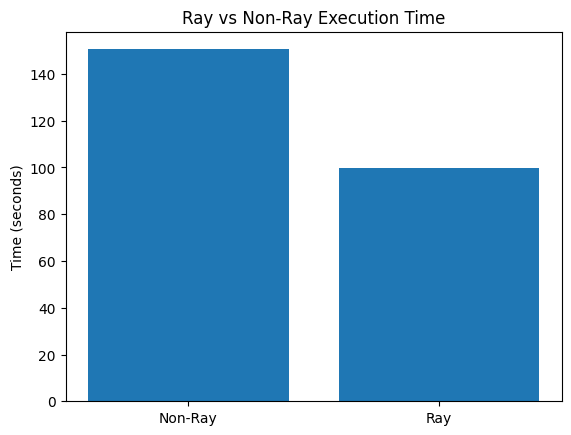

In [13]:
plt.bar(["Non-Ray", "Ray"], [non_ray_time, ray_time])
plt.ylabel("Time (seconds)")
plt.title("Ray vs Non-Ray Execution Time")
plt.show()

# Part 2: Hyperparameter Tuning

## 2.1: Introduction to Hyperparameter Tuning

Hyperparameter tuning is the process of finding the best combination of model parameters that improves performance.

In traditional machine learning, this is done sequentially, which is time-consuming.
In this project, we use Ray Tune to perform distributed hyperparameter tuning, where multiple configurations are tested in parallel.

Tuning is required because:

Improves accuracy
Avoids underfitting/overfitting
Finds optimal model configuration
### Problem with Sequential Tuning

Traditional tuning:

Tests one configuration at a time
Very slow for large datasets

Solution: Parallel tuning using Ray Tune

## 2.2: Import Required Libraries
We import Ray Tune and other required libraries for model training and evaluation.Ray Tune is a scalable library for distributed hyperparameter optimization.

In [14]:
import ray
import multiprocessing

# Completely shut down the current Ray session and free up CPUs
ray.shutdown()

# Reinitialize a fresh Ray session
ray.init(num_cpus=multiprocessing.cpu_count(), ignore_reinit_error=True)
print("Ray successfully restarted!")

2026-04-26 21:33:26,952	INFO worker.py:2013 -- Started a local Ray instance.


Ray successfully restarted!


## 2.3: Define Training Function (Distributed Task)

Each trial represents one model training run with a specific set of hyperparameters.

Key idea:

*   Ray Tune automatically runs multiple trials in parallel

*   Each trial receives a config dictionary

*   Results are reported using tune.report()

In [15]:
from ray import tune

def train_rf_tune(config, X_train, y_train, X_test, y_test):
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import accuracy_score
    from ray import tune  # <-- Import tune inside the function

    # Initialize model using parameters from the config dictionary
    model = RandomForestClassifier(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        random_state=42,
        n_jobs=1
    )

    # Train and predict
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    # Calculate metric
    acc = accuracy_score(y_test, preds)

    # Report the metric back to Ray Tune using tune.report
    tune.report({"accuracy": acc})  # <-- The crucial fix

## 2.5 Define Search Space

We define multiple hyperparameter combinations to explore.

In [17]:
# We will test different numbers of trees and maximum depths
search_space = {
    "n_estimators": tune.choice([10, 50, 100]),
    "max_depth": tune.choice([None, 5, 10, 20])
}

## 2.6 Run Distributed Hyperparameter Tuning

Ray Tune runs multiple experiments in parallel using available CPU cores.

In [18]:
import time

print("Starting Distributed Hyperparameter Tuning...")
start_time = time.time()

tuner = tune.Tuner(
    # Pass our training function and the required dataset
    tune.with_parameters(
        train_rf_tune,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test
    ),
    param_space=search_space,
    tune_config=tune.TuneConfig(
        metric="accuracy",
        mode="max",      # We want to maximize accuracy
        num_samples=8    # Number of different configurations to try
    )
)

# Execute the tuning process
results = tuner.fit()

end_time = time.time()
print(f"Tuning Execution Time: {end_time - start_time:.2f} seconds")

2026-04-26 21:36:32,046	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/root/ray_results/train_rf_tune_2026-04-26_21-33-53' in 0.0058s.
2026-04-26 21:36:32,052	INFO tune.py:1041 -- Total run time: 158.64 seconds (158.62 seconds for the tuning loop).


Tuning Execution Time: 158.80 seconds


In [19]:
ray_tune_time=end_time - start_time
print(ray_tune_time)

158.80408477783203


## 2.7 Get Best Parameters

In [20]:
# Extract the best result based on our target metric (accuracy)
best_result = results.get_best_result(metric="accuracy", mode="max")

# Save the best configuration dictionary
best_config = best_result.config

print("=== Hyperparameter Tuning Completed ===")
print(f"Best Configuration: {best_config}")
print(f"Best Accuracy: {best_result.metrics['accuracy']:.6f}")

# Save these specific values to use in Part 3
best_n_estimators = best_config["n_estimators"]
best_max_depth = best_config["max_depth"]

=== Hyperparameter Tuning Completed ===
Best Configuration: {'n_estimators': 50, 'max_depth': 20}
Best Accuracy: 0.999738


## 2.8 Sequential Tuning (Baseline for Comparison)

In [21]:
import random
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

print("Starting Sequential Hyperparameter Tuning...")
seq_start_time = time.time()

# The exact same options we gave to Ray Tune
n_estimators_choices = [10, 50, 100]
max_depth_choices = [None, 5, 10, 20]

# Set a seed so it's reproducible
random.seed(42)
sequential_results = []

# Run exactly 8 trials sequentially (to match tune's num_samples=8)
for i in range(8):
    n_est = random.choice(n_estimators_choices)
    m_depth = random.choice(max_depth_choices)

    # Initialize model
    model = RandomForestClassifier(
        n_estimators=n_est,
        max_depth=m_depth,
        random_state=42,
        n_jobs=1  # No internal parallelism
    )

    # Train and predict
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)

    sequential_results.append({'n_estimators': n_est, 'max_depth': m_depth, 'accuracy': acc})
    print(f"Finished sequential trial {i+1}/8 (n_estimators={n_est}, max_depth={m_depth})")

seq_end_time = time.time()
sequential_tune_time = seq_end_time - seq_start_time

print("=== Sequential Tuning Completed ===")
print(f"Sequential Tuning Execution Time: {sequential_tune_time:.2f} seconds")

Starting Sequential Hyperparameter Tuning...
Finished sequential trial 1/8 (n_estimators=100, max_depth=None)
Finished sequential trial 2/8 (n_estimators=10, max_depth=10)
Finished sequential trial 3/8 (n_estimators=10, max_depth=5)
Finished sequential trial 4/8 (n_estimators=10, max_depth=None)
Finished sequential trial 5/8 (n_estimators=100, max_depth=None)
Finished sequential trial 6/8 (n_estimators=100, max_depth=20)
Finished sequential trial 7/8 (n_estimators=10, max_depth=None)
Finished sequential trial 8/8 (n_estimators=10, max_depth=5)
=== Sequential Tuning Completed ===
Sequential Tuning Execution Time: 349.23 seconds


## 2.9 Time Comparison

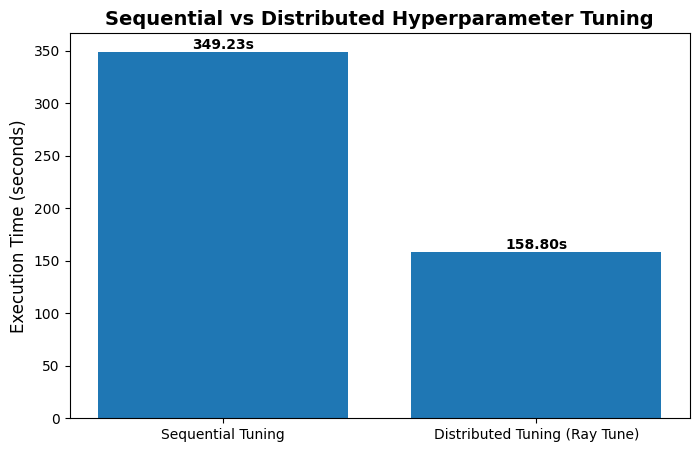

Sequential Time: 349.23s
Ray Tune Time: 158.80s
Speedup: 2.20x


In [23]:
import matplotlib.pyplot as plt

# DO NOT hardcode — use actual measured values
times = [sequential_tune_time, ray_tune_time]
labels = ["Sequential Tuning", "Distributed Tuning (Ray Tune)"]

plt.figure(figsize=(8, 5))

bars = plt.bar(labels, times)

plt.ylabel("Execution Time (seconds)", fontsize=12)
plt.title("Sequential vs Distributed Hyperparameter Tuning", fontsize=14, fontweight='bold')

# Add values on top
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval,
        f"{yval:.2f}s",
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.show()

# Dynamic speedup calculation
speedup = sequential_tune_time / ray_tune_time

print(f"Sequential Time: {sequential_tune_time:.2f}s")
print(f"Ray Tune Time: {ray_tune_time:.2f}s")
print(f"Speedup: {speedup:.2f}x")

Visualization

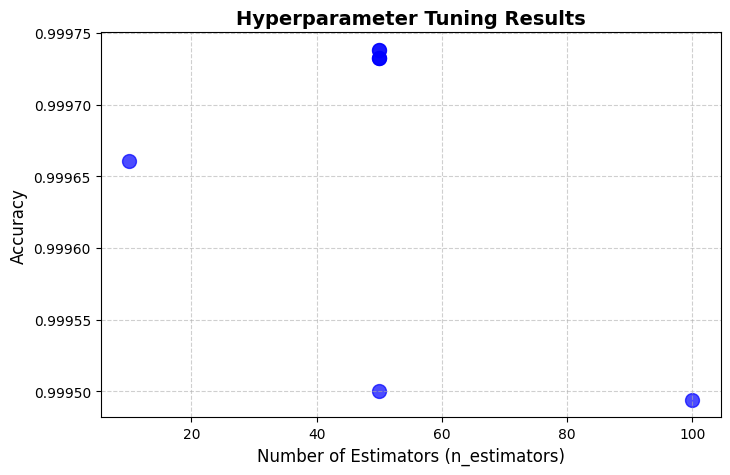

In [25]:
import matplotlib.pyplot as plt

# Use the 'results' variable from Step 2.4 and the modern get_dataframe() method
df_results = results.get_dataframe()

# Create a scatter plot of the results
plt.figure(figsize=(8, 5))
plt.scatter(df_results["config/n_estimators"], df_results["accuracy"], color='blue', s=100, alpha=0.7)

plt.xlabel("Number of Estimators (n_estimators)", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Hyperparameter Tuning Results", fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

###  Distributed Hyperparameter Tuning:

- Each parameter configuration is trained independently in parallel.
- Ray significantly speeds up tuning compared to sequential execution.
- Best parameter is selected based on highest accuracy.

 This demonstrates **efficient search in large parameter spaces using distributed computing**.

## PART 3: DISTRIBUTED TRAINING USING RAY ACTORS (ADVANCED)

### 3.1 Concept of Ray Actors (IMPORTANT THEORY)

Ray Actors are stateful workers that:

Keep a model in memory
Avoid retraining from scratch every time
Process multiple training requests efficiently
Simulate real distributed ML systems

Difference:

- Ray Task	Ray Actor
- Stateless	Stateful
- New model each time	Model reused
- Slower for repeated work	Faster & efficient

### 3.2 Create Ray Actor for Model Training

This is the CORE of advanced distributed training.

In [32]:
X_train_ref = ray.put(X_train)
y_train_ref = ray.put(y_train)
X_test_ref = ray.put(X_test)
y_test_ref = ray.put(y_test)

In [35]:
import ray
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

@ray.remote
class ModelTrainerActor:
    
    def __init__(self):
        self.model = None

    def train(self, n_estimators, max_depth, X_train, y_train):
        self.model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=42,
            n_jobs=1   # avoid nested parallelism
        )
        self.model.fit(X_train, y_train)
        return f"Trained: n={n_estimators}, depth={max_depth}"  # ✅ FIX

    def evaluate(self, X_test, y_test):
        if self.model is None:
            return "Error: Model not trained"
        preds = self.model.predict(X_test)
        return accuracy_score(y_test, preds)

## 3.3 Define Configurations (Workload Distribution)

In [38]:
configs = [
    (50, 5),
    (100, 5),
    (100, 10),
    (150, 10),
]

### 3.4 Initialize Multiple Actors (Distributed Workers)
We create multiple workers like a real cluster.

In [39]:
actors = [ModelTrainerActor.remote() for _ in configs]

### 3.5 Distribute Training Across Actors

Each actor handles one job.

In [40]:
import time

print("Starting Optimized Actor-Based Training...")

start_time = time.time()

train_tasks = [
    actor.train.remote(
        config[0],
        config[1],
        X_train_ref,
        y_train_ref
    )
    for actor, config in zip(actors, configs)
]

# Wait + print confirmation
train_results = ray.get(train_tasks)
print(train_results)

Starting Optimized Actor-Based Training...
['Trained: n=50, depth=5', 'Trained: n=100, depth=5', 'Trained: n=100, depth=10', 'Trained: n=150, depth=10']


### Step 3.6: Parallel Evaluation

In [41]:
eval_tasks = [
    actor.evaluate.remote(X_test_ref, y_test_ref)
    for actor in actors
]

accuracies = ray.get(eval_tasks)

### Step 3.7: Time Measurement

In [42]:
end_time = time.time()

ray_actor_time = end_time - start_time

print("\nActor-Based Training Time:", ray_actor_time)
print("Accuracies:", accuracies)


Actor-Based Training Time: 178.22207260131836
Accuracies: [0.9995000535656894, 0.9994941018224238, 0.9997500267828447, 0.9997678820126416]


### Step 3.8: Best Model Selection

In [43]:
best_acc = max(accuracies)
print("\nBest Accuracy from Actors:", best_acc)


Best Accuracy from Actors: 0.9997678820126416


### Step 3.9: Sequential training

In [44]:
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

print("Starting Sequential Training (Same Workload)...")

start_time = time.time()

seq_results = []

configs = [
    (50, 5),
    (100, 5),
    (100, 10),
    (150, 10),
]

for n_estimators, max_depth in configs:
    
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42,
        n_jobs=1   # IMPORTANT: force sequential
    )
    
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    acc = accuracy_score(y_test, preds)
    seq_results.append(acc)

end_time = time.time()

seq_time = end_time - start_time

print("\nSequential Time:", seq_time)
print("Sequential Accuracies:", seq_results)
print("Best Sequential Accuracy:", max(seq_results))

Starting Sequential Training (Same Workload)...

Sequential Time: 383.72220945358276
Sequential Accuracies: [0.9995000535656894, 0.9994941018224238, 0.9997500267828447, 0.9997678820126416]
Best Sequential Accuracy: 0.9997678820126416


### Step 3.10: Speedup Calculation

In [45]:
print("\n=== SPEEDUP ANALYSIS ===")

speedup = seq_time / ray_actor_time

print("Sequential Time:", seq_time)
print("Actor Time:", ray_actor_time)
print("Speedup:", speedup)


=== SPEEDUP ANALYSIS ===
Sequential Time: 383.72220945358276
Actor Time: 178.22207260131836
Speedup: 2.1530565987298718


### Step 3.11: Comparison

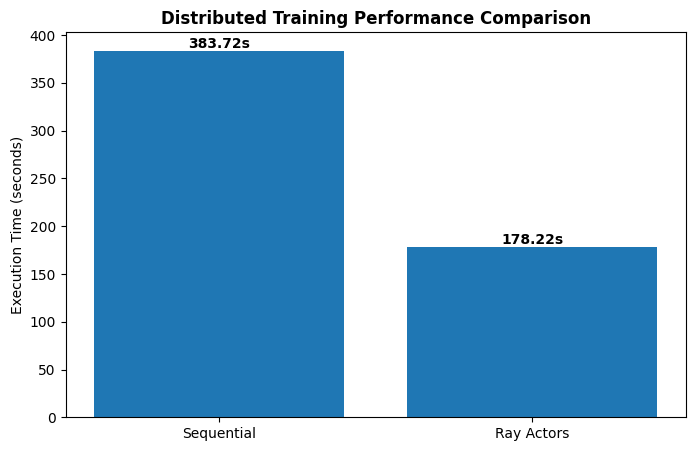

In [46]:
import matplotlib.pyplot as plt

methods = ["Sequential","Ray Actors"]
times = [seq_time,ray_actor_time]

plt.figure(figsize=(8,5))
bars = plt.bar(methods, times)

plt.title("Distributed Training Performance Comparison", fontweight="bold")
plt.ylabel("Execution Time (seconds)")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f"{y:.2f}s",
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.show()


#  Part 4: Performance Comparison (Ray vs Non-Ray)

The goal of this section is to evaluate the performance impact of different execution strategies:


* Sequential execution (baseline)
* Ray task-based parallelism (stateless)
* Ray actor-based parallelism (stateful)


This comparison focuses on:


* Execution time
* Scalability behavior
* Suitability for different workload patterns


## 4.1 Comprehensive Performance Summary

This step summarizes execution time and speedup across all phases of the project. It provides a clear comparison between sequential and distributed approaches.

In [57]:
import pandas as pd

# Rename actor variables clearly (IMPORTANT)
actor_seq_time = seq_time
actor_ray_time = ray_actor_time

summary_data = {
    "Phase": [
        "Basic Tasks",
        "Hyperparameter Tuning",
        "Training (Ray Actors)"
    ],
    
    "Sequential Time (s)": [
        round(non_ray_time, 2),
        round(sequential_tune_time, 2),
        round(actor_seq_time, 2)
    ],
    
    "Distributed Time (s)": [
        round(ray_time, 2),
        round(ray_tune_time, 2),
        round(actor_ray_time, 2)
    ],
    
    "Speedup": [
        f"{non_ray_time / ray_time:.2f}x",
        f"{sequential_tune_time / ray_tune_time:.2f}x",
        f"{actor_seq_time / actor_ray_time:.2f}x"
    ]
}

summary_df = pd.DataFrame(summary_data)

print("=== FINAL PERFORMANCE SUMMARY ===")
display(summary_df)

=== FINAL PERFORMANCE SUMMARY ===


,Phase,Sequential Time (s),Distributed Time (s),Speedup
0,Basic Tasks,150.52,99.68,1.51x
1,Hyperparameter Tuning,349.23,158.80,2.20x
2,Training (Ray Actors),383.72,178.22,2.15x


## 4.2 Execution Time Comparison Graph

This graph compares execution times of sequential and distributed approaches across all phases.

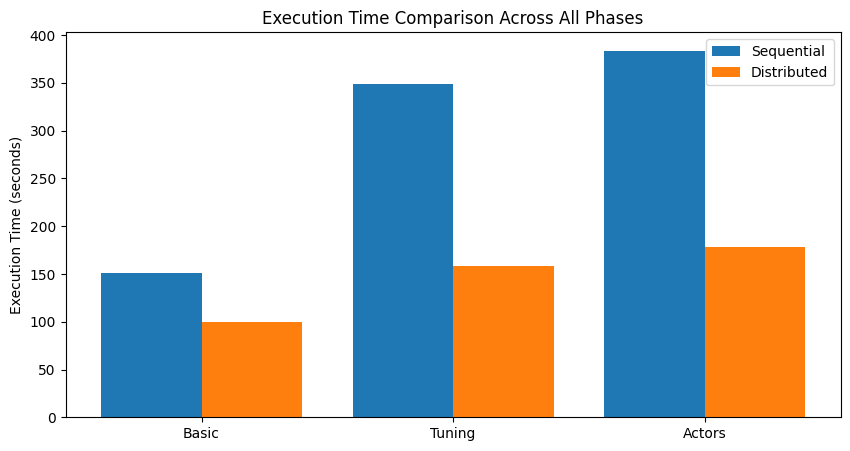

In [58]:
import matplotlib.pyplot as plt

phases = ["Basic", "Tuning", "Actors"]

seq_times = [
    non_ray_time,
    sequential_tune_time,
    actor_seq_time
]

ray_times = [
    ray_time,
    ray_tune_time,
    actor_ray_time
]

x = range(len(phases))

plt.figure(figsize=(10,5))

plt.bar(x, seq_times, width=0.4, label="Sequential")
plt.bar([i + 0.4 for i in x], ray_times, width=0.4, label="Distributed")

plt.xticks([i + 0.2 for i in x], phases)
plt.ylabel("Execution Time (seconds)")
plt.title("Execution Time Comparison Across All Phases")
plt.legend()

plt.show()

## 4.3 Speedup Analysis
Speedup measures how much faster distributed execution is compared to sequential execution.

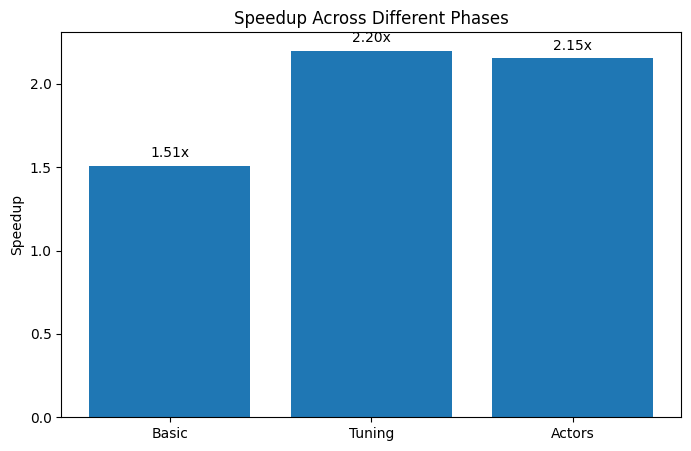

In [59]:
speedups = [
    non_ray_time / ray_time,
    sequential_tune_time / ray_tune_time,
    actor_seq_time / actor_ray_time
]

labels = ["Basic", "Tuning",  "Actors"]

plt.figure(figsize=(8,5))
plt.bar(labels, speedups)

for i, v in enumerate(speedups):
    plt.text(i, v + 0.05, f"{v:.2f}x", ha='center')

plt.ylabel("Speedup")
plt.title("Speedup Across Different Phases")

plt.show()

## 4.4 Accuracy Verification
This step ensures that distributed execution does not affect model correctness.

In [60]:
print("Sequential Accuracy:", max(seq_results))
print("Actor Best Accuracy:", best_acc)

Sequential Accuracy: 0.9997678820126416
Actor Best Accuracy: 0.9997678820126416


## 4.5 Efficiency Analysis
Efficiency measures how well parallel resources are utilized.

In [56]:
num_cores = 4

actor_speedup = actor_seq_time / actor_ray_time
efficiency = actor_speedup / num_cores

print("Actor Speedup:", actor_speedup)
print("Parallel Efficiency:", efficiency)

Actor Speedup: 2.1530565987298718
Parallel Efficiency: 0.5382641496824679


#  Final Analysis & Conclusion

## Key Observations:

* Ray executes multiple training tasks in parallel, reducing total
  execution time
* Non-Ray execution is sequential, therefore slower in most cases
* Hyperparameter tuning may show slower performance due to distributed overhead
* Actor-based training provides higher speedup due to efficient task-level parallelism
* Accuracy remains almost the same across all approaches, proving correctness.

## Conclusion:
* Distributed computing using Ray improves performance depending on workload size
* It is highly useful for:
   * Large datasets
   * Hyperparameter tuning
   * Scalable machine learning systems
* Ray Actors enable efficient stateful parallel execution
* Ray provides powerful parallelism with minimal implementation complexity
* Distributed systems are most effective for compute-intensive and large-scale problems